In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
from scipy.stats import uniform
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

In [29]:
bins = [0, 3, 7, 10]
labels = ['No_estresado', 'Normal', 'Estresado']
df['stress_category'] = pd.cut(df['stress_level'], bins=bins, labels=labels)

In [30]:
print(df['stress_category'].value_counts())

stress_category
Normal          7930
No_estresado    6089
Estresado       5981
Name: count, dtype: int64


In [31]:
X = df.drop(columns=['stress_level', 'stress_category', 'student_id', 'productivity_score'], errors='ignore')
y = df['stress_category']

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [33]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [34]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

def evaluar_clasificador(modelo, X_train, X_test, y_train, y_test):
    modelo.fit(X_train, y_train)
    y_pred_train = modelo.predict(X_train)
    y_pred_test = modelo.predict(X_test)
    
    metricas = {
        'Accuracy_train': accuracy_score(y_train, y_pred_train),
        'Accuracy_test': accuracy_score(y_test, y_pred_test),
        'Reporte_train': classification_report(y_train, y_pred_train, output_dict=True),
        'Reporte_test': classification_report(y_test, y_pred_test, output_dict=True),
        'Matriz_test': confusion_matrix(y_test, y_pred_test)
    }
    return metricas

## Regresión Logística

In [35]:
logreg = LogisticRegression(max_iter=1000, random_state=42, multi_class='multinomial')
logreg.fit(X_train_scaled, y_train)
metricas_logreg = evaluar_clasificador(logreg, X_train_scaled, X_test_scaled, y_train, y_test)

## Modelos basados en arboles 

### Árbol de Decisión para Clasificación

In [36]:
dt_clf = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_clf.fit(X_train_scaled, y_train)
metricas_dt_clf = evaluar_clasificador(dt_clf, X_train_scaled, X_test_scaled, y_train, y_test)

### Random Forest para Clasificación

In [37]:
rf_clf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_clf.fit(X_train_scaled, y_train)
metricas_rf_clf = evaluar_clasificador(rf_clf, X_train_scaled, X_test_scaled, y_train, y_test)

### Modelos de Boosting

#### Gradient Boosting para Clasificación

In [38]:
gb_clf = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb_clf.fit(X_train_scaled, y_train)
metricas_gb_clf = evaluar_clasificador(gb_clf, X_train_scaled, X_test_scaled, y_train, y_test)

#### AdaBoost para Clasificación

In [39]:
ada_clf = AdaBoostClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
ada_clf.fit(X_train_scaled, y_train)
metricas_ada_clf = evaluar_clasificador(ada_clf, X_train_scaled, X_test_scaled, y_train, y_test)

In [40]:
resultados_clf = [
    {'Modelo': 'Regresión Logística', 'Acc_train': metricas_logreg['Accuracy_train'], 'Acc_test': metricas_logreg['Accuracy_test']},
    {'Modelo': 'Árbol de Decisión', 'Acc_train': metricas_dt_clf['Accuracy_train'], 'Acc_test': metricas_dt_clf['Accuracy_test']},
    {'Modelo': 'Random Forest', 'Acc_train': metricas_rf_clf['Accuracy_train'], 'Acc_test': metricas_rf_clf['Accuracy_test']},
    {'Modelo': 'Gradient Boosting', 'Acc_train': metricas_gb_clf['Accuracy_train'], 'Acc_test': metricas_gb_clf['Accuracy_test']},
    {'Modelo': 'AdaBoost', 'Acc_train': metricas_ada_clf['Accuracy_train'], 'Acc_test': metricas_ada_clf['Accuracy_test']}
]

df_resultados_clf = pd.DataFrame(resultados_clf).sort_values('Acc_test', ascending=False)
df_resultados_clf.reset_index(drop=True, inplace=True)

print("=== COMPARATIVA DE MODELOS DE CLASIFICACIÓN ===\n")
print(df_resultados_clf.to_string(index=False))

print("\n=== REPORTE DETALLADO POR MODELO ===\n")
modelos_entrenados = {
    'Regresión Logística': logreg,
    'Árbol de Decisión': dt_clf,
    'Random Forest': rf_clf,
    'Gradient Boosting': gb_clf,
    'AdaBoost': ada_clf
}

for nombre, modelo in modelos_entrenados.items():
    print(f"--- {nombre} ---")
    y_pred = modelo.predict(X_test_scaled)
    print(classification_report(y_test, y_pred))
    print("Matriz de confusión:")
    print(confusion_matrix(y_test, y_pred))
    print("-" * 50)

=== COMPARATIVA DE MODELOS DE CLASIFICACIÓN ===

             Modelo  Acc_train  Acc_test
Regresión Logística   0.396125   0.39650
  Árbol de Decisión   0.400938   0.39525
           AdaBoost   0.397000   0.39525
      Random Forest   0.560000   0.39300
  Gradient Boosting   0.454688   0.38950

=== REPORTE DETALLADO POR MODELO ===

--- Regresión Logística ---
              precision    recall  f1-score   support

   Estresado       0.00      0.00      0.00      1196
No_estresado       0.25      0.00      0.00      1218
      Normal       0.40      1.00      0.57      1586

    accuracy                           0.40      4000
   macro avg       0.22      0.33      0.19      4000
weighted avg       0.23      0.40      0.23      4000

Matriz de confusión:
[[   0    4 1192]
 [   0    2 1216]
 [   0    2 1584]]
--------------------------------------------------
--- Árbol de Decisión ---
              precision    recall  f1-score   support

   Estresado       0.22      0.01      0.01      

In [26]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, title, X, y, cv=5, train_sizes=np.linspace(0.1, 1.0, 10)):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=-1, train_sizes=train_sizes,
        scoring='neg_mean_squared_error')
    
    train_scores_mean = -train_scores.mean(axis=1)
    test_scores_mean = -test_scores.mean(axis=1)
    train_scores_std = train_scores.std(axis=1)
    test_scores_std = test_scores.std(axis=1)

    plt.figure(figsize=(10,6))
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Entrenamiento")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Validación cruzada")
    plt.xlabel("Tamaño del conjunto de entrenamiento")
    plt.ylabel("MSE (escala logarítmica)")
    plt.yscale('log')
    plt.title(f"Curva de aprendizaje: {title}")
    plt.legend(loc="best")
    plt.grid(True)
    plt.show()

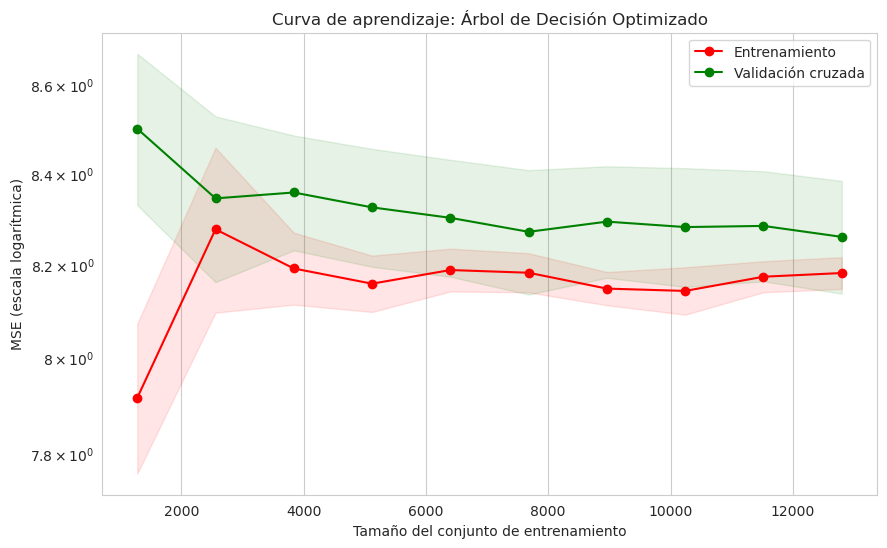

KeyboardInterrupt: 

In [ ]:
plot_learning_curve(mejor_dt, "Árbol de Decisión Optimizado", X_train_scaled, y_train)

plot_learning_curve(mejor_rf, "Random Forest Optimizado", X_train_scaled, y_train)

plot_learning_curve(mejor_gb, "Gradient Boosting Optimizado", X_train_scaled, y_train)